<h2>Logistic Regression</h2>

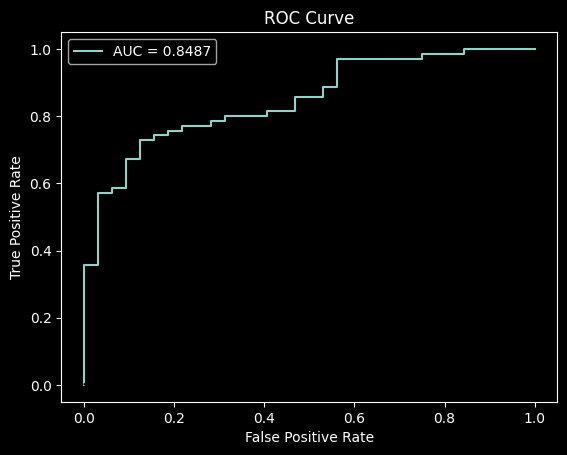

CROSS-VALIDATION SUMMARY

Per-Fold AUC:
  Fold 1: AUC = 0.7885
  Fold 2: AUC = 0.8519
  Fold 3: AUC = 0.9127
  Fold 4: AUC = 0.8269
  Fold 5: AUC = 0.8487

Mean AUC: 0.8457 +/- Std Dev 0.0452

Averaged Classification Metrics Across Folds:
                   precision     recall   f1-score    support
  -------------------------------------------------------
  0                   0.6389     0.8285     0.7007       45.6
  1                   0.8944     0.5321     0.5795       56.4
  macro avg           0.7667     0.6803     0.6401      102.0
  weighted avg        0.7757     0.6941     0.6527      102.0
  accuracy            0.6941


In [1]:
from tabnanny import verbose

import numpy as np
from sqlalchemy.dialects.oracle.dictionary import dual

from src.models.experiment_runner import run_cv_experiment
from src.utils.utils import load_config

_ = run_cv_experiment('logistic_regression', verbose=True)

<h2>Random forest</h2>

Training model: random_forest with threshold 5%
Training model: random_forest with threshold 5%
Training model: random_forest with threshold 5%
Training model: random_forest with threshold 5%
Training model: random_forest with threshold 5%


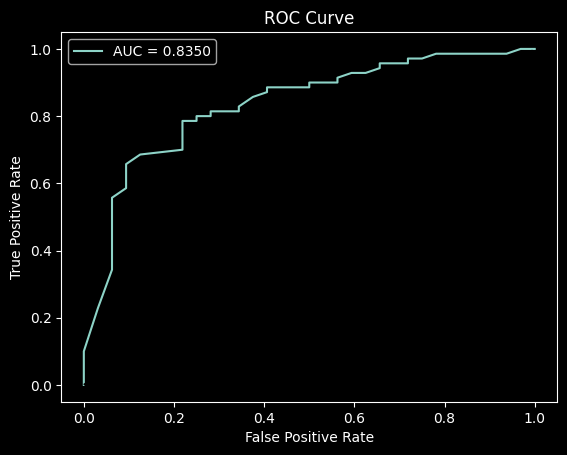

CROSS-VALIDATION SUMMARY

Per-Fold AUC:
  Fold 1: AUC = 0.8008
  Fold 2: AUC = 0.8630
  Fold 3: AUC = 0.9144
  Fold 4: AUC = 0.8207
  Fold 5: AUC = 0.8350

Mean AUC: 0.8468 +/- Std Dev 0.0441

Averaged Classification Metrics Across Folds:
                   precision     recall   f1-score    support
  -------------------------------------------------------
  0                   0.7444     0.7033     0.7095       45.6
  1                   0.7831     0.7829     0.7733       56.4
  macro avg           0.7638     0.7431     0.7414      102.0
  weighted avg        0.7710     0.7588     0.7539      102.0
  accuracy            0.7588
Training model: random_forest with threshold 5%


In [4]:
from src.models.experiment_runner import run_cv_experiment
_ = run_cv_experiment('random_forest', verbose=True)

<h2>XGBoost</h2>

Training model: xgboost with threshold 5%
Training model: xgboost with threshold 5%
Training model: xgboost with threshold 5%
Training model: xgboost with threshold 5%
Training model: xgboost with threshold 5%


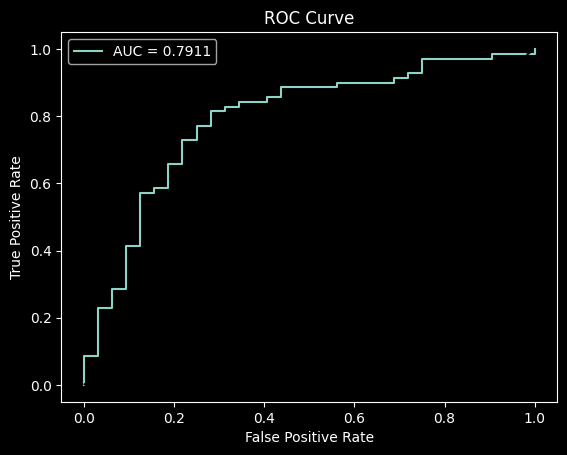

CROSS-VALIDATION SUMMARY

Per-Fold AUC:
  Fold 1: AUC = 0.7689
  Fold 2: AUC = 0.8530
  Fold 3: AUC = 0.8927
  Fold 4: AUC = 0.8289
  Fold 5: AUC = 0.7911

Mean AUC: 0.8269 +/- Std Dev 0.0491

Averaged Classification Metrics Across Folds:
                   precision     recall   f1-score    support
  -------------------------------------------------------
  0                   0.7326     0.6958     0.6934       45.6
  1                   0.7906     0.7788     0.7743       56.4
  macro avg           0.7616     0.7373     0.7339      102.0
  weighted avg        0.7685     0.7608     0.7513      102.0
  accuracy            0.7608
Training model: xgboost with threshold 5%


In [5]:
from src.models.experiment_runner import run_cv_experiment
_ = run_cv_experiment('xgboost', verbose=True)

<h2>LightGBM</h2>

Training model: lightgbm with threshold 5%
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 45, number of negative: 27
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 231
[LightGBM] [Info] Number of data points in the train set: 72, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.625000 -> initscore=0.510826
[LightGBM] [Info] Start training from score 0.510826
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

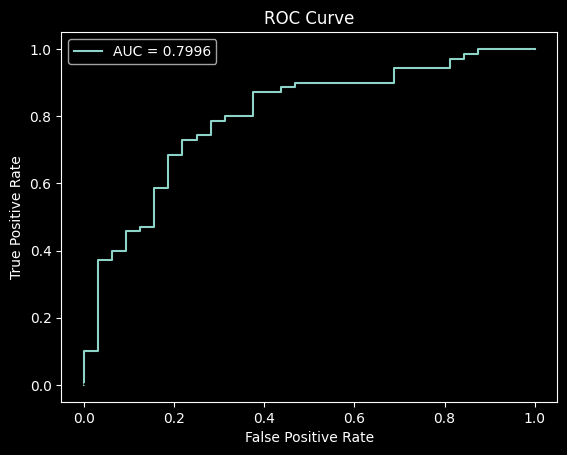

CROSS-VALIDATION SUMMARY

Per-Fold AUC:
  Fold 1: AUC = 0.7855
  Fold 2: AUC = 0.8565
  Fold 3: AUC = 0.9004
  Fold 4: AUC = 0.8521
  Fold 5: AUC = 0.7996

Mean AUC: 0.8388 +/- Std Dev 0.0465

Averaged Classification Metrics Across Folds:
                   precision     recall   f1-score    support
  -------------------------------------------------------
  0                   0.7121     0.7135     0.6958       45.6
  1                   0.7969     0.7574     0.7662       56.4
  macro avg           0.7545     0.7355     0.7310      102.0
  weighted avg        0.7644     0.7549     0.7470      102.0
  accuracy            0.7549
Training model: lightgbm with threshold 5%
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 355, number of negative: 257
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000203 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [

In [6]:
from src.models.experiment_runner import run_cv_experiment
_ = run_cv_experiment('lightgbm', verbose=True)

<h2>LightGBM hyperparameter tuning using Optuna</h2>

In [1]:
import optuna
from src.models.experiment_runner import run_cv_experiment

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 63),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 30),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "verbosity": -1,
        "random_state": 42,
    }

    results = run_cv_experiment(
        model_type="lightgbm",
        verbose=False,
        **params
    )

    mean_auc = results["cv_mean_auc"]
    std_auc = results["cv_std_auc"]

    # stability-aware objective
    return mean_auc - 0.1 * std_auc


def tune_lightgbm(n_trials=40):
    study = optuna.create_study(direction="maximize", study_name="lightgbm_tuning")

    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print("\nBest Trial:")
    print(f"AUC: {study.best_value:.4f}")
    print("Params:")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")

    return study

tune_lightgbm()

C:\Users\nityunj.goel\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-10 17:01:30,501] A new study created in memory with name: lightgbm_tuning
Best trial: 0. Best value: 0.846819:   2%|▎         | 1/40 [00:02<01:25,  2.20s/it]

[I 2026-04-10 17:01:32,703] Trial 0 finished with value: 0.8468187614463172 and parameters: {'n_estimators': 265, 'learning_rate': 0.028224069084116264, 'num_leaves': 17, 'max_depth': 7, 'min_child_samples': 22, 'subsample': 0.9537508576458271, 'colsample_bytree': 0.6264832291958907, 'reg_alpha': 0.47870752343627243, 'reg_lambda': 0.022054256718052074}. Best is trial 0 with value: 0.8468187614463172.


Best trial: 1. Best value: 0.847607:   5%|▌         | 2/40 [00:02<00:42,  1.12s/it]

[I 2026-04-10 17:01:33,057] Trial 1 finished with value: 0.8476067898354269 and parameters: {'n_estimators': 202, 'learning_rate': 0.019532610879907295, 'num_leaves': 47, 'max_depth': 5, 'min_child_samples': 14, 'subsample': 0.853662907435784, 'colsample_bytree': 0.662031815019081, 'reg_alpha': 0.06670352173384442, 'reg_lambda': 0.0013083184834699576}. Best is trial 1 with value: 0.8476067898354269.


Best trial: 1. Best value: 0.847607:   8%|▊         | 3/40 [00:02<00:29,  1.28it/s]

...

[I 2026-04-10 17:01:51,531] Trial 37 finished with value: 0.8452547164162121 and parameters: {'n_estimators': 253, 'learning_rate': 0.030236282138656905, 'num_leaves': 37, 'max_depth': 5, 'min_child_samples': 22, 'subsample': 0.6324171547042462, 'colsample_bytree': 0.622879903339252, 'reg_alpha': 0.012590793251441922, 'reg_lambda': 4.0454596758935475}. Best is trial 23 with value: 0.8505512471842954.


Best trial: 23. Best value: 0.850551:  98%|█████████▊| 39/40 [00:21<00:00,  1.75it/s]

[I 2026-04-10 17:01:52,216] Trial 38 finished with value: 0.8413619712324455 and parameters: {'n_estimators': 359, 'learning_rate': 0.02100613939833545, 'num_leaves': 21, 'max_depth': 6, 'min_child_samples': 17, 'subsample': 0.7350146839309798, 'colsample_bytree': 0.6914091651317237, 'reg_alpha': 0.02859940198999006, 'reg_lambda': 1.2778668806450741}. Best is trial 23 with value: 0.8505512471842954.


Best trial: 23. Best value: 0.850551: 100%|██████████| 40/40 [00:22<00:00,  1.81it/s]

[I 2026-04-10 17:01:52,624] Trial 39 finished with value: 0.8460369936956117 and parameters: {'n_estimators': 225, 'learning_rate': 0.025887296308672723, 'num_leaves': 53, 'max_depth': 3, 'min_child_samples': 19, 'subsample': 0.7760932799205705, 'colsample_bytree': 0.6526468859045691, 'reg_alpha': 0.0015226332074642578, 'reg_lambda': 1.8954066045210767}. Best is trial 23 with value: 0.8505512471842954.

Best Trial:
AUC: 0.8506
Params:
  n_estimators: 266
  learning_rate: 0.01188996214597206
  num_leaves: 58
  max_depth: 6
  min_child_samples: 13
  subsample: 0.8275336294975119
  colsample_bytree: 0.646361426224116
  reg_alpha: 0.00657760571422226
  reg_lambda: 0.002292584023916076


<h2>Logistic regression hyperparameter tuning</h2>

In [1]:
import optuna
import numpy as np
from src.models.experiment_runner import run_cv_experiment

def objective(trial):
    penalty = trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet", "none"])

    solver = trial.suggest_categorical(
        "solver",
        ["liblinear", "lbfgs", "newton-cg", "newton-cholesky", "sag", "saga"]
    )

    if penalty == "l1" and solver not in ["liblinear", "saga"]:
        return 0.0

    if penalty == "elasticnet" and solver != "saga":
        return 0.0

    if penalty == "none" and solver not in ["lbfgs", "newton-cg", "newton-cholesky", "sag", "saga"]:
        return 0.0

    if penalty == "elasticnet":
        l1_ratio = trial.suggest_float("l1_ratio", 1e-3, 1 - 1e-3)
        c = trial.suggest_float("C", 1e-6, 10.0, log=True)
    elif penalty == "l1":
        l1_ratio = 1
        c = trial.suggest_float("C", 1e-6, 10.0, log=True)
    elif penalty == "l2":
        l1_ratio = 0
        c = trial.suggest_float("C", 1e-6, 10.0, log=True)
    else:
        c = np.inf
        l1_ratio = 0.5

    params = {
        "C": c,
        "l1_ratio": l1_ratio,
        "solver": solver,
        "max_iter": 1000,
        "random_state": 42,
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
    }

    results = run_cv_experiment(
        model_type="logistic_regression",
        **params
    )

    return results["cv_mean_auc"] - 0.1 * results["cv_std_auc"]


def tune_logreg(n_trials=300):
    study = optuna.create_study(direction="maximize", study_name="logreg_tuning")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print("\nBest Trial:")
    print(f"AUC: {study.best_value:.4f}")
    print("Params:")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")

    return study

tune_logreg(1500)

C:\Users\nityunj.goel\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-11 00:15:53,994] A new study created in memory with name: logreg_tuning
Best trial: 0. Best value: 0:   0%|          | 0/1500 [00:00<?, ?it/s]

[I 2026-04-11 00:15:53,994] Trial 0 finished with value: 0.0 and parameters: {'penalty': 'elasticnet', 'solver': 'lbfgs'}. Best is trial 0 with value: 0.0.


Best trial: 1. Best value: 0.852044:   0%|          | 2/1500 [00:00<02:27, 10.12it/s]C:\Users\nityunj.goel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=None)
  warnings.warn(
C:\Users\nityunj.goel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


[I 2026-04-11 00:15:54,187] Trial 1 finished with value: 0.8520443526905259 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.08283719182611024, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.8520443526905259.
[I 2026-04-11 00:15:54,353] Trial 2 finished with value: 0.8453148751029356 and parameters: {'penalty': 'l2', 'solver': 'sag', 'C': 0.7281573264285504, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.8520443526905259.


C:\Users\nityunj.goel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=None)
  warnings.warn(
C:\Users\nityunj.goel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\nityunj.goel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=None)
  warnings.warn(
C:\Users\nityunj.goel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\nityunj.goel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.p

...

[I 2026-04-11 00:20:03,752] Trial 1494 finished with value: 0.7015229236899189 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'l1_ratio': 0.16676256296310055, 'C': 0.002490725102527582, 'class_weight': 'balanced'}. Best is trial 1428 with value: 0.8669876943004023.
[I 2026-04-11 00:20:03,917] Trial 1495 finished with value: 0.863228482438026 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'l1_ratio': 0.19432669352374157, 'C': 0.011669376322223224, 'class_weight': 'balanced'}. Best is trial 1428 with value: 0.8669876943004023.
[I 2026-04-11 00:20:03,926] Trial 1496 finished with value: 0.0 and parameters: {'penalty': 'elasticnet', 'solver': 'newton-cg'}. Best is trial 1428 with value: 0.8669876943004023.


Best trial: 1428. Best value: 0.866988: 100%|█████████▉| 1499/1500 [04:10<00:00,  7.19it/s]

[I 2026-04-11 00:20:04,103] Trial 1497 finished with value: 0.7871146653848834 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'l1_ratio': 0.15135638386090694, 'C': 0.00535233376357378, 'class_weight': 'balanced'}. Best is trial 1428 with value: 0.8669876943004023.
[I 2026-04-11 00:20:04,261] Trial 1498 finished with value: 0.8668810823496702 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'l1_ratio': 0.17552722734453546, 'C': 0.008709124011892392, 'class_weight': 'balanced'}. Best is trial 1428 with value: 0.8669876943004023.


Best trial: 1428. Best value: 0.866988: 100%|██████████| 1500/1500 [04:10<00:00,  5.99it/s]

[I 2026-04-11 00:20:04,418] Trial 1499 finished with value: 0.7852883987090724 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'l1_ratio': 0.18056246296361522, 'C': 0.004540088069290655, 'class_weight': 'balanced'}. Best is trial 1428 with value: 0.8669876943004023.

Best Trial:
AUC: 0.8670
Params:
  penalty: elasticnet
  solver: saga
  l1_ratio: 0.18264649920874743
  C: 0.009061642080807474
  class_weight: balanced


<h2>Logistic Regression performance on hold out test set</h2>

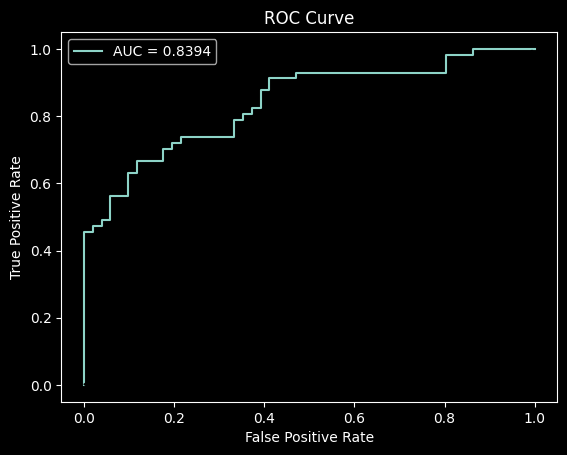

Holdout AUC: 0.8394

              precision    recall  f1-score   support

           0       0.76      0.63      0.69        51
           1       0.71      0.82      0.76        57

    accuracy                           0.73       108
   macro avg       0.74      0.73      0.73       108
weighted avg       0.74      0.73      0.73       108



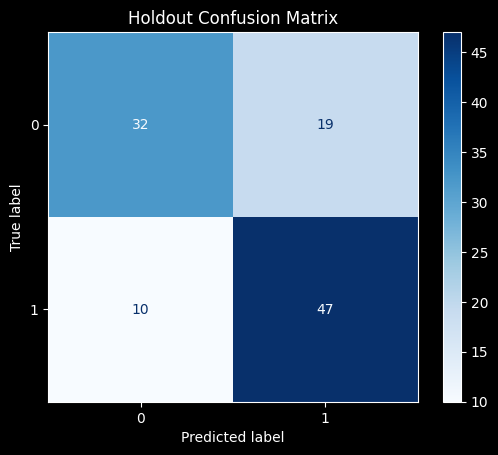

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from src.models.eval import plot_roc_curve_and_auc
import matplotlib.pyplot as plt

params = {
        "C": 0.009061642080807474,
        "l1_ratio": 0.18264649920874743,
        "solver": "saga",
        "max_iter": 1000,
        "class_weight": "balanced",
        "random_state": 42,
    }
results = run_cv_experiment('logistic_regression', **params)


pipeline = results["final_pipeline"]
X_holdout, y_holdout = results["holdout"]

y_pred = pipeline.predict(X_holdout)
pos_idx = list(pipeline.classes_).index(1)
y_proba = pipeline.predict_proba(X_holdout)[:, pos_idx]

# AUC & ROC curve
auc = plot_roc_curve_and_auc(y_holdout, y_proba, plot_roc_curve=True)
print(f"Holdout AUC: {auc:.4f}\n")

# Classification report
print(classification_report(y_holdout, y_pred))

# Confusion matrix
cm = confusion_matrix(y_holdout, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
disp.plot(cmap="Blues")
plt.title("Holdout Confusion Matrix")
plt.show()

Fold 1: MAE=12.50  RMSE=17.46  R²=-0.2299
Fold 2: MAE=10.72  RMSE=15.95  R²=0.5617
Fold 3: MAE=16.84  RMSE=24.47  R²=0.5955
Fold 4: MAE=15.87  RMSE=30.15  R²=0.3674
Fold 5: MAE=27.57  RMSE=37.61  R²=0.0570

── CV Summary ──
  MAE: 16.6983 ± 6.5602
  RMSE: 25.1269 ± 9.0070
  R²: 0.2704 ± 0.3521

── Holdout Performance ──
  MAE:  17.28
  RMSE: 26.32
  R²:   -0.9484


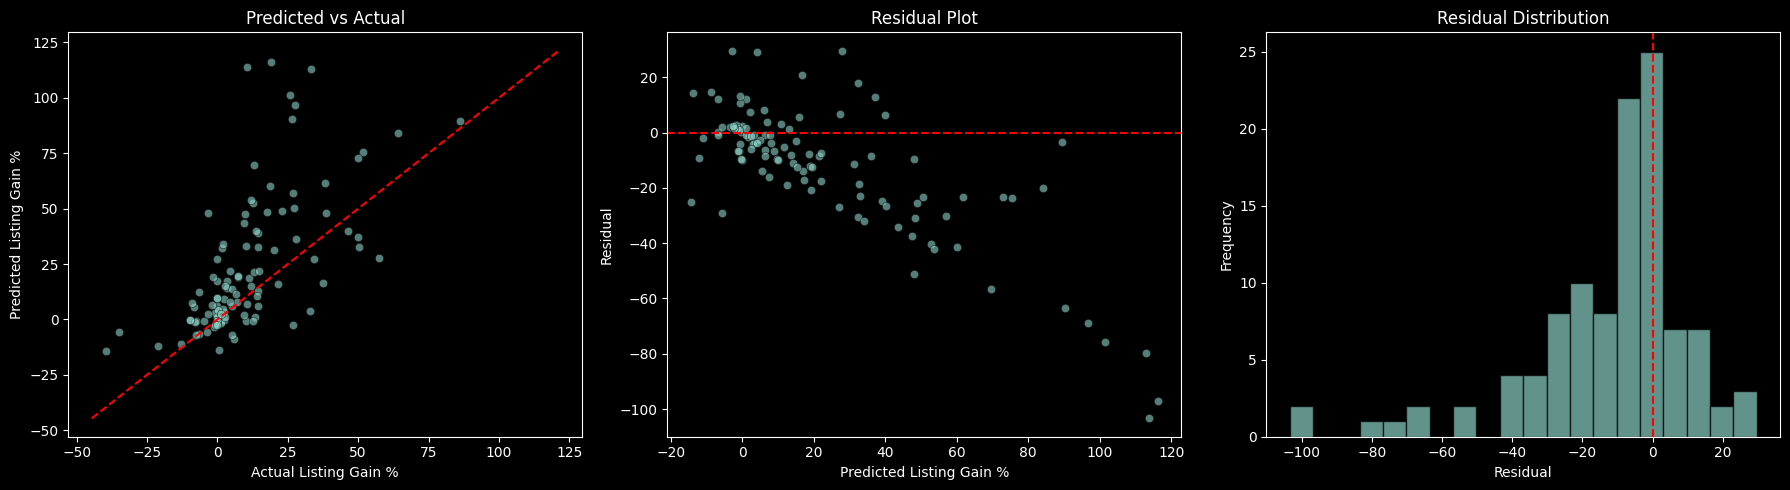


── Feature Importances ──
              feature  importance
           Retail (x)         286
            Total (x)         258
              NII (x)         253
              QIB (x)         242
Issue Amount (Rs.cr.)         200
            qib_ratio         183
         retail_ratio         180
            nii_ratio         180
      price_band_high         180
                 year         162
       price_band_low         101
         gmp_on_close          70
       is_gmp_missing          20


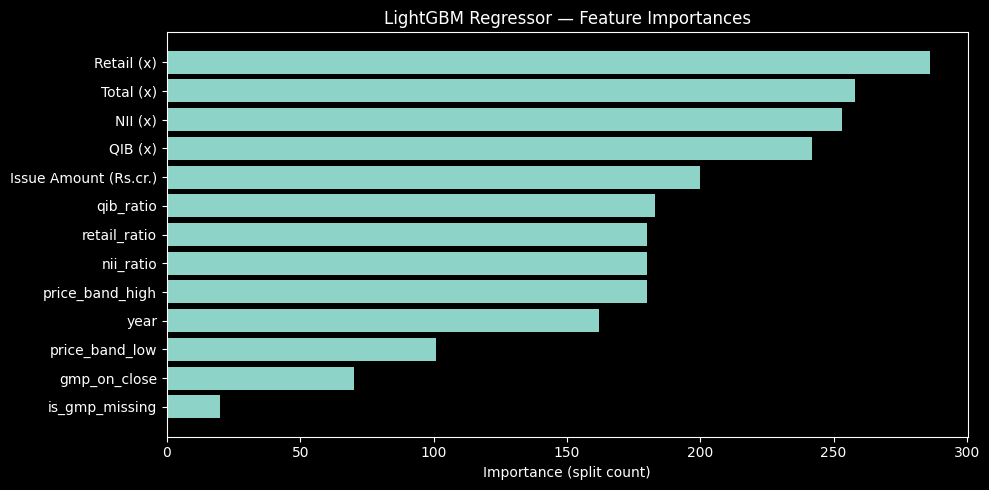

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── helpers ──────────────────────────────────────────────────────────────────

def compute_continuous_target(df: pd.DataFrame) -> pd.Series:
    """Listing gain percentage (continuous)."""
    return (
        (df[TARGET["listing_price"]] - df[TARGET["issue_price"]])
        / df[TARGET["issue_price"]]
        * 100
    )


def build_lgbm_regressor_pipeline(**lgbm_kwargs) -> Pipeline:
    """Data pipeline → LGBMRegressor."""
    lgbm_kwargs.setdefault("verbosity", -1)
    lgbm_kwargs.setdefault("random_state", 42)

    data_pipeline = get_data_pipeline(mode="strict")

    return Pipeline([
        ("data", data_pipeline),
        ("model", LGBMRegressor(**lgbm_kwargs)),
    ])


# ── experiment runner (regression) ───────────────────────────────────────────

def run_regression_cv(verbose=True, **lgbm_kwargs):
    df = load_raw_dataset()
    config = load_config()
    date_col = RAW_FEATURES["listing_date"]
    cv_cfg = config["cv"]
    n_splits = cv_cfg["n_splits"]
    gap = cv_cfg["gap"]
    holdout_fraction = cv_cfg["holdout_fraction"]

    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)
    y = compute_continuous_target(df)

    # hold out most-recent IPOs
    holdout_start = len(df) - math.ceil(len(df) * holdout_fraction)
    X_cv, X_holdout = df.iloc[:holdout_start], df.iloc[holdout_start:]
    y_cv, y_holdout = y.iloc[:holdout_start], y.iloc[holdout_start:]

    splitter = TimeSeriesSplit(n_splits=n_splits, gap=gap)
    fold_metrics = []

    for fold, (tr_idx, val_idx) in enumerate(splitter.split(X_cv), start=1):
        X_train, X_val = X_cv.iloc[tr_idx], X_cv.iloc[val_idx]
        y_train, y_val = y_cv.iloc[tr_idx], y_cv.iloc[val_idx]

        pipeline = build_lgbm_regressor_pipeline(**lgbm_kwargs)
        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_val)
        mae = mean_absolute_error(y_val, y_pred)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)

        fold_metrics.append({"fold": fold, "MAE": mae, "RMSE": rmse, "R²": r2})
        if verbose:
            print(f"Fold {fold}: MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}")

    fold_df = pd.DataFrame(fold_metrics)

    if verbose:
        print("\n── CV Summary ──")
        for col in ["MAE", "RMSE", "R²"]:
            print(f"  {col}: {fold_df[col].mean():.4f} ± {fold_df[col].std():.4f}")

    # final model on full CV window
    final_pipeline = build_lgbm_regressor_pipeline(**lgbm_kwargs)
    final_pipeline.fit(X_cv, y_cv)

    return {
        "fold_metrics": fold_df,
        "final_pipeline": final_pipeline,
        "holdout": (X_holdout, y_holdout),
    }


# ── run experiment & evaluate on holdout ─────────────────────────────────────

results = run_regression_cv(verbose=True)

pipeline = results["final_pipeline"]
X_holdout, y_holdout = results["holdout"]
y_pred = pipeline.predict(X_holdout)

mae = mean_absolute_error(y_holdout, y_pred)
rmse = np.sqrt(mean_squared_error(y_holdout, y_pred))
r2 = r2_score(y_holdout, y_pred)

print(f"\n── Holdout Performance ──")
print(f"  MAE:  {mae:.2f}")
print(f"  RMSE: {rmse:.2f}")
print(f"  R²:   {r2:.4f}")

# ── plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Predicted vs Actual
axes[0].scatter(y_holdout, y_pred, alpha=0.6, edgecolors="k", linewidths=0.5)
lims = [min(y_holdout.min(), y_pred.min()) - 5, max(y_holdout.max(), y_pred.max()) + 5]
axes[0].plot(lims, lims, "r--", lw=1.5)
axes[0].set_xlabel("Actual Listing Gain %")
axes[0].set_ylabel("Predicted Listing Gain %")
axes[0].set_title("Predicted vs Actual")

# 2. Residuals
residuals = y_holdout.values - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, edgecolors="k", linewidths=0.5)
axes[1].axhline(0, color="r", ls="--", lw=1.5)
axes[1].set_xlabel("Predicted Listing Gain %")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual Plot")

# 3. Residual distribution
axes[2].hist(residuals, bins=20, edgecolor="k", alpha=0.7)
axes[2].axvline(0, color="r", ls="--", lw=1.5)
axes[2].set_xlabel("Residual")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

# ── feature importances ──────────────────────────────────────────────────────
lgbm_model = pipeline.named_steps["model"]
importances = lgbm_model.feature_importances_

data_step = pipeline.named_steps["data"]
X_sample = data_step.transform(X_holdout)
feature_names = X_sample.columns.tolist()

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values("importance", ascending=False)

print("\n── Feature Importances ──")
print(imp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(imp_df["feature"], imp_df["importance"])
ax.set_xlabel("Importance (split count)")
ax.set_title("LightGBM Regressor — Feature Importances")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

<h2>Naive Baseline Comparison</h2>

In [3]:
import math
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from configs.feature_config import RAW_FEATURES, TARGET
from src.pipelines.data_pipeline import get_data_pipeline
from src.utils.utils import load_config, load_raw_dataset
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline

def compute_continuous_target(df):
    return (df[TARGET["listing_price"]] - df[TARGET["issue_price"]]) / df[TARGET["issue_price"]] * 100

df = load_raw_dataset()
config = load_config()
date_col = RAW_FEATURES["listing_date"]
cv_cfg = config["cv"]

df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col).reset_index(drop=True)
y = compute_continuous_target(df)

holdout_start = len(df) - math.ceil(len(df) * cv_cfg["holdout_fraction"])
X_cv, X_holdout = df.iloc[:holdout_start], df.iloc[holdout_start:]
y_cv, y_holdout = y.iloc[:holdout_start], y.iloc[holdout_start:]

splitter = TimeSeriesSplit(n_splits=cv_cfg["n_splits"], gap=cv_cfg["gap"])

# ── models to compare ────────────────────────────────────────────────────────

def make_lgbm_pipeline():
    return Pipeline([
        ("data", get_data_pipeline(mode="strict")),
        ("model", LGBMRegressor(verbosity=-1, random_state=42)),
    ])

models = {
    "Dummy (mean)":   lambda: DummyRegressor(strategy="mean"),
    "Dummy (median)": lambda: DummyRegressor(strategy="median"),
    "LightGBM":       make_lgbm_pipeline,
}

# ── run CV + holdout for each ─────────────────────────────────────────────────

summary_rows = []

for name, model_fn in models.items():
    fold_results = []
    is_pipeline = name == "LightGBM"

    for fold, (tr_idx, val_idx) in enumerate(splitter.split(X_cv), start=1):
        X_train, X_val = X_cv.iloc[tr_idx], X_cv.iloc[val_idx]
        y_train, y_val = y_cv.iloc[tr_idx], y_cv.iloc[val_idx]

        model = model_fn()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        fold_results.append({
            "MAE": mean_absolute_error(y_val, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_val, y_pred)),
            "R²": r2_score(y_val, y_pred),
        })

    fold_df = pd.DataFrame(fold_results)

    # holdout
    model = model_fn()
    model.fit(X_cv, y_cv)
    y_pred_ho = model.predict(X_holdout)

    summary_rows.append({
        "Model": name,
        "CV MAE": f'{fold_df["MAE"].mean():.2f} ± {fold_df["MAE"].std():.2f}',
        "CV RMSE": f'{fold_df["RMSE"].mean():.2f} ± {fold_df["RMSE"].std():.2f}',
        "CV R²": f'{fold_df["R²"].mean():.4f} ± {fold_df["R²"].std():.4f}',
        "Holdout MAE": f'{mean_absolute_error(y_holdout, y_pred_ho):.2f}',
        "Holdout RMSE": f'{np.sqrt(mean_squared_error(y_holdout, y_pred_ho)):.2f}',
        "Holdout R²": f'{r2_score(y_holdout, y_pred_ho):.4f}',
    })

    # print per-fold detail
    print(f"── {name} per-fold ──")
    for i, r in enumerate(fold_results, 1):
        print(f"  Fold {i}: MAE={r['MAE']:.2f}  RMSE={r['RMSE']:.2f}  R²={r['R²']:.4f}")
    print()

# ── comparison table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame(summary_rows)
print("=" * 90)
print("MODEL COMPARISON (Dummy baselines vs LightGBM Regressor)")
print("=" * 90)
print(comparison.to_string(index=False))

# verdict
lgbm_row = summary_rows[-1]
dummy_mean_row = summary_rows[0]
lgbm_ho_r2 = float(lgbm_row["Holdout R²"])
dummy_ho_r2 = float(dummy_mean_row["Holdout R²"])

print("\n── Verdict ──")
if lgbm_ho_r2 > 0 and lgbm_ho_r2 > dummy_ho_r2:
    print("✓ LightGBM beats the naive baseline on holdout → there IS learnable signal.")
elif lgbm_ho_r2 > dummy_ho_r2:
    print("⚠ LightGBM beats dummy but holdout R² is negative → weak/unstable signal.")
else:
    print("✗ LightGBM does NOT beat the naive baseline → no reliable signal detected.")

── Dummy (mean) per-fold ──
  Fold 1: MAE=16.95  RMSE=19.58  R²=-0.5470
  Fold 2: MAE=19.37  RMSE=24.57  R²=-0.0406
  Fold 3: MAE=28.68  RMSE=39.28  R²=-0.0423
  Fold 4: MAE=23.36  RMSE=37.99  R²=-0.0047
  Fold 5: MAE=27.21  RMSE=40.37  R²=-0.0864

── Dummy (median) per-fold ──
  Fold 1: MAE=11.08  RMSE=15.76  R²=-0.0013
  Fold 2: MAE=16.93  RMSE=24.35  R²=-0.0223
  Fold 3: MAE=27.95  RMSE=41.79  R²=-0.1797
  Fold 4: MAE=22.39  RMSE=39.89  R²=-0.1075
  Fold 5: MAE=28.68  RMSE=44.76  R²=-0.3358

── LightGBM per-fold ──
  Fold 1: MAE=12.50  RMSE=17.46  R²=-0.2299
  Fold 2: MAE=10.72  RMSE=15.95  R²=0.5617
  Fold 3: MAE=16.84  RMSE=24.47  R²=0.5955
  Fold 4: MAE=15.87  RMSE=30.15  R²=0.3674
  Fold 5: MAE=27.57  RMSE=37.61  R²=0.0570

MODEL COMPARISON (Dummy baselines vs LightGBM Regressor)
         Model       CV MAE       CV RMSE            CV R² Holdout MAE Holdout RMSE Holdout R²
  Dummy (mean) 23.11 ± 4.99  32.36 ± 9.59 -0.1442 ± 0.2270       17.84        21.20    -0.2641
Dummy (media